--- DATOS DE ENTRENAMIENTO ---
Radiografías Normales: 1341
Radiografías con Neumonía: 3875
Total: 5216



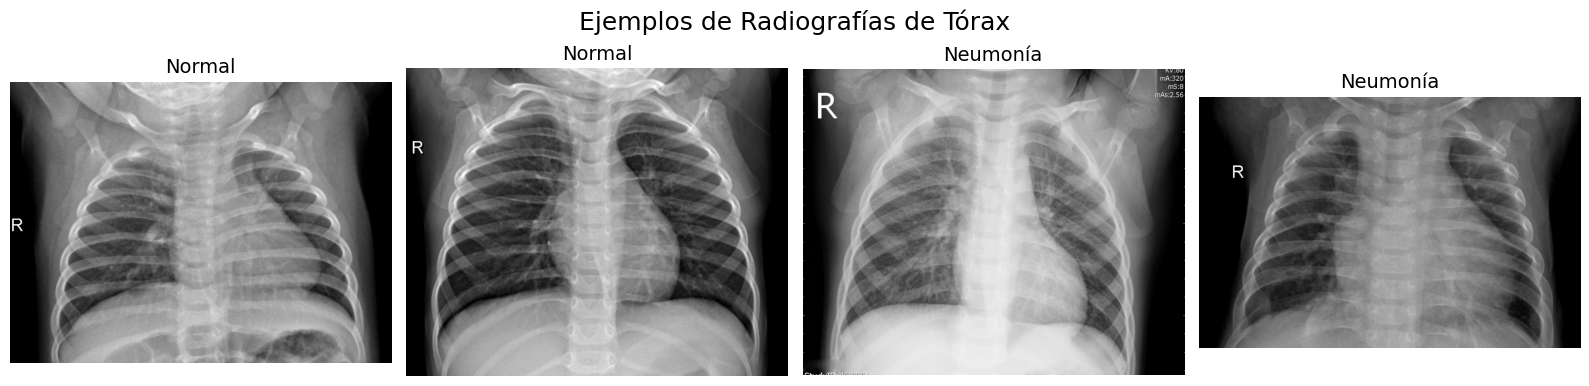

In [1]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


base_dir = './data/chest_xray'
train_dir = os.path.join(base_dir, 'train')
train_normal_dir = os.path.join(train_dir, 'NORMAL')
train_pneumonia_dir = os.path.join(train_dir, 'PNEUMONIA')

num_normal = len(os.listdir(train_normal_dir))
num_pneum = len(os.listdir(train_pneumonia_dir))
print(f"--- DATOS DE ENTRENAMIENTO ---")
print(f"Radiografías Normales: {num_normal}")
print(f"Radiografías con Neumonía: {num_pneum}")
print(f"Total: {num_normal + num_pneum}\n")

normal_imgs = [os.path.join(train_normal_dir, img) for img in random.sample(os.listdir(train_normal_dir), 2)]
pneum_imgs = [os.path.join(train_pneumonia_dir, img) for img in random.sample(os.listdir(train_pneumonia_dir), 2)]
all_imgs = normal_imgs + pneum_imgs
labels = ['Normal', 'Normal', 'Neumonía', 'Neumonía']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Ejemplos de Radiografías de Tórax', fontsize=18)

for i, ax in enumerate(axes):
    img = mpimg.imread(all_imgs[i])
    ax.imshow(img, cmap='gray')
    ax.set_title(labels[i], fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

print("Configurando los Generadores de Datos con partición rigurosa...")
train_val_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest',
    validation_split=0.20
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

print("\nInstanciando iterador de Entrenamiento:")
train_generator = train_val_datagen.flow_from_directory(
    'data/chest_xray/train',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

print("Instanciando iterador de Validación:")
val_generator = train_val_datagen.flow_from_directory(
    'data/chest_xray/train',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

print("Instanciando iterador de Test (Ciego):")
test_generator = test_datagen.flow_from_directory(
    'data/chest_xray/test',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nPipeline de datos construido. Clases detectadas:", train_generator.class_indices)

I0000 00:00:1787522068.403599  643017 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787522068.443767  643017 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787522069.523997  643017 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Configurando los Generadores de Datos con partición rigurosa...

Instanciando iterador de Entrenamiento:
Found 4173 images belonging to 2 classes.
Instanciando iterador de Validación:
Found 1043 images belonging to 2 classes.
Instanciando iterador de Test (Ciego):
Found 624 images belonging to 2 classes.

Pipeline de datos construido. Clases detectadas: {'NORMAL': 0, 'PNEUMONIA': 1}


In [3]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

print("Descargando el modelo base VGG16 preentrenado (ImageNet)...")


base_model = VGG16(
    weights='imagenet',   
    include_top=False,      
    input_shape=(224, 224, 3) 
)

base_model.trainable = False

model = Sequential([
    base_model,
    
    GlobalAveragePooling2D(), 
    
    Dense(256, activation='relu'), 
    
    Dropout(0.5), 
    
    Dense(1, activation='sigmoid') 
])

print(" Compilando el modelo con el optimizador...")
model.compile(
    optimizer='adam',                
    loss='binary_crossentropy',       
    metrics=['accuracy']           
)

print("\n Arquitectura construida con éxito. Resumen del modelo:")
model.summary()

Descargando el modelo base VGG16 preentrenado (ImageNet)...


I0000 00:00:1787522070.483356  643017 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5067 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:01:00.0, compute capability: 8.6


 Compilando el modelo con el optimizador...

 Arquitectura construida con éxito. Resumen del modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [4]:
total_imagenes = num_normal + num_pneum
peso_clase_0 = (1 / num_normal) * (total_imagenes / 2.0) 
peso_clase_1 = (1 / num_pneum) * (total_imagenes / 2.0)  

pesos_clases = {0: peso_clase_0, 1: peso_clase_1}

print(f"Peso para clase Normal (0): {peso_clase_0:.2f}")
print(f"Peso para clase Neumonía (1): {peso_clase_1:.2f}")

Peso para clase Normal (0): 1.94
Peso para clase Neumonía (1): 0.67


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='binary_crossentropy',          
    metrics=['accuracy']                 
)

early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=5,               
    restore_best_weights=True 
)


checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_neumonia.h5', 
    monitor='val_loss',
    save_best_only=True        
)

print("Iniciando el entrenamiento en la GPU...")
history = model.fit(
    train_generator,           
    epochs=30,                
    validation_data=val_generator, 
    callbacks=[early_stop, checkpoint],
    class_weight=pesos_clases
)
print("¡Entrenamiento finalizado!")

Iniciando el entrenamiento en la GPU...
Epoch 1/30


I0000 00:00:1787522072.152540  643017 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1787522073.250334  643288 service.cc:153] XLA service 0x7c6968035dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787522073.250353  643288 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787522073.276529  643288 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787522073.596437  643288 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787522073.630160  643288 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2054__.63


  1/131 ━━━━━━━━━━━━━━━━━━━━ 25:11 12s/step - accuracy: 0.2812 - loss: 0.8043

I0000 00:00:1787522083.607127  643288 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 85/131 ━━━━━━━━━━━━━━━━━━━━ 17s 382ms/step - accuracy: 0.4736 - loss: 0.7262

...

131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 449ms/step - accuracy: 0.9197 - loss: 0.2134 - val_accuracy: 0.8993 - val_loss: 0.2428
Epoch 20/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9200 - loss: 0.2019

131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 445ms/step - accuracy: 0.9173 - loss: 0.2072 - val_accuracy: 0.9128 - val_loss: 0.2205
Epoch 21/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 439ms/step - accuracy: 0.9188 - loss: 0.2092 - val_accuracy: 0.8984 - val_loss: 0.2479
Epoch 22/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 436ms/step - accuracy: 0.9202 - loss: 0.2034 - val_accuracy: 0.9022 - val_loss: 0.2400
Epoch 23/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 444ms/step - accuracy: 0.9228 - loss: 0.2015 - val_accuracy: 0.9041 - val_loss: 0.2434
Epoch 24/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9170 - loss: 0.2067

131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 437ms/step - accuracy: 0.9219 - loss: 0.2016 - val_accuracy: 0.9204 - val_loss: 0.2158
Epoch 25/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9135 - loss: 0.2029

131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 439ms/step - accuracy: 0.9209 - loss: 0.1948 - val_accuracy: 0.9070 - val_loss: 0.2120
Epoch 26/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 428ms/step - accuracy: 0.9221 - loss: 0.1961 - val_accuracy: 0.9156 - val_loss: 0.2155
Epoch 27/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9218 - loss: 0.2037

131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 439ms/step - accuracy: 0.9224 - loss: 0.1950 - val_accuracy: 0.9233 - val_loss: 0.1955
Epoch 28/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 435ms/step - accuracy: 0.9281 - loss: 0.1915 - val_accuracy: 0.9233 - val_loss: 0.1984
Epoch 29/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 445ms/step - accuracy: 0.9262 - loss: 0.1878 - val_accuracy: 0.9243 - val_loss: 0.2011
Epoch 30/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 446ms/step - accuracy: 0.9298 - loss: 0.1874 - val_accuracy: 0.9204 - val_loss: 0.2093
¡Entrenamiento finalizado!


In [6]:
print("\nIniciando examen final con las 624 imágenes de Test...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n¡NOTA FINAL (Accuracy) en Test: {test_acc * 100:.2f}%!")


Iniciando examen final con las 624 imágenes de Test...
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 438ms/step - accuracy: 0.8814 - loss: 0.2757

¡NOTA FINAL (Accuracy) en Test: 88.14%!


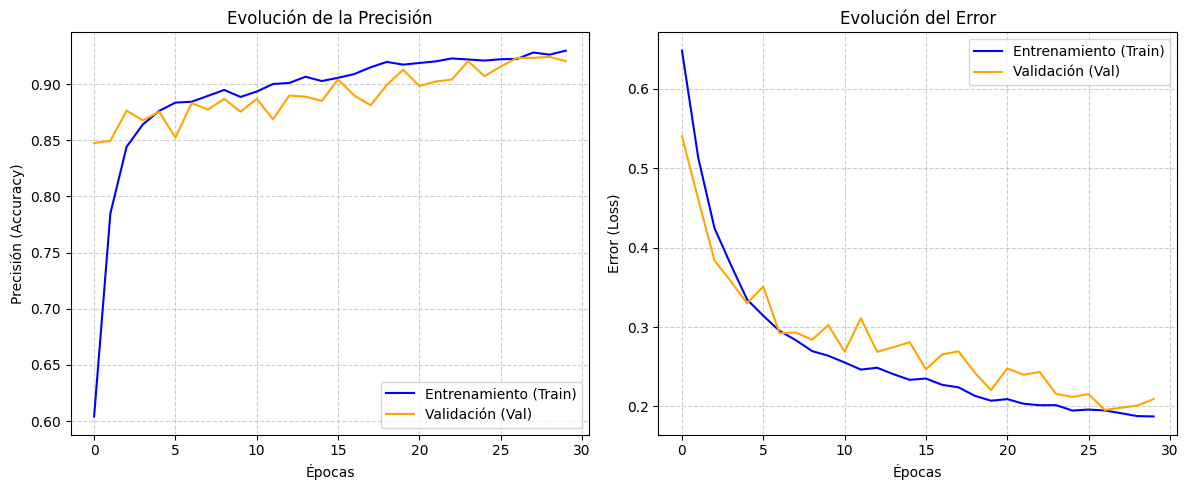

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento (Train)', color='blue')
plt.plot(history.history['val_accuracy'], label='Validación (Val)', color='orange')
plt.title('Evolución de la Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento (Train)', color='blue')
plt.plot(history.history['val_loss'], label='Validación (Val)', color='orange')
plt.title('Evolución del Error')
plt.xlabel('Épocas')
plt.ylabel('Error (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [8]:
model.save('mejor_modelo_neumonia.keras')
print("¡Modelo guardado también en formato .keras moderno!")

¡Modelo guardado también en formato .keras moderno!


In [9]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


base_model = model.get_layer('vgg16')

base_model.trainable = True

for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

early_stop_ft = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint_ft = ModelCheckpoint(filepath='modelo_finetuning_tfg.keras', monitor='val_loss', save_best_only=True)

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Iniciando Fine-Tuning en la GPU...")
history_ft = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop_ft, checkpoint_ft],
    class_weight=pesos_clases
)

print("\nEvaluando con las imágenes de Test ciego...")
test_loss_ft, test_acc_ft = model.evaluate(test_generator)
print(f"\n¡Precisión FINAL tras Fine-Tuning: {test_acc_ft * 100:.2f}%!")

Iniciando Fine-Tuning en la GPU...
Epoch 1/10


I0000 00:00:1787523853.061337  643285 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27920__.63


111/131 ━━━━━━━━━━━━━━━━━━━━ 7s 357ms/step - accuracy: 0.9147 - loss: 0.2029

I0000 00:00:1787523895.933756  643286 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27920__.63


131/131 ━━━━━━━━━━━━━━━━━━━━ 67s 477ms/step - accuracy: 0.9331 - loss: 0.1652 - val_accuracy: 0.9453 - val_loss: 0.1406
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 434ms/step - accuracy: 0.9521 - loss: 0.1245 - val_accuracy: 0.9616 - val_loss: 0.1132
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 435ms/step - accuracy: 0.9549 - loss: 0.1147 - val_accuracy: 0.9549 - val_loss: 0.1098
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 453ms/step - accuracy: 0.9662 - loss: 0.0800 - val_accuracy: 0.9741 - val_loss: 0.0750
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 60s 458ms/step - accuracy: 0.9758 - loss: 0.0659 - val_accuracy: 0.9684 - val_loss: 0.0853
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 62s 471ms/step - accuracy: 0.9777 - loss: 0.0610 - val_accuracy: 0.9262 - val_loss: 0.1964
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 479ms/step - accuracy: 0.9784 - loss: 0.0530 - val_accuracy: 0.9645 - val_loss: 0.0896

Evaluando con las imágenes de Test ciego...
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accura

El modelo está diagnosticando las imágenes de Test...
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 224ms/step


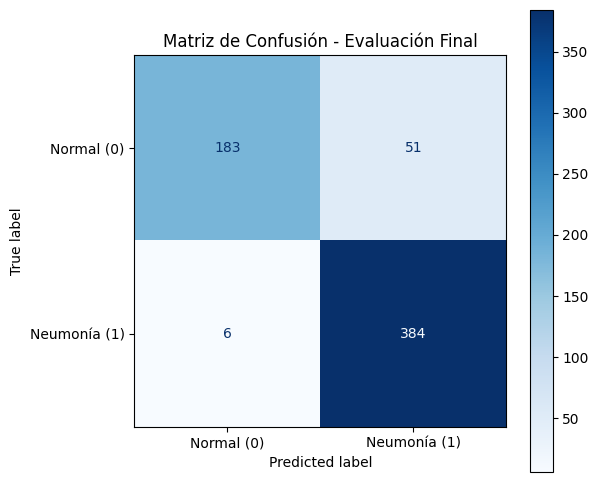

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Y_true = test_generator.classes

test_generator.reset()

print("El modelo está diagnosticando las imágenes de Test...")
Y_pred_probs = model.predict(test_generator)

Y_pred = (Y_pred_probs > 0.5).astype('int32') 

cm = confusion_matrix(Y_true, Y_pred)
nombres = ['Normal (0)', 'Neumonía (1)']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusión - Evaluación Final')
plt.show()

In [11]:
from sklearn.metrics import classification_report

informe = classification_report(
    Y_true, 
    Y_pred, 
    target_names=['Normal', 'Neumonía'],
    digits=4
)

print("="*60)
print("       INFORME DE CLASIFICACIÓN CLÍNICA (MÉTRICAS TFG)")
print("="*60)
print(informe)

       INFORME DE CLASIFICACIÓN CLÍNICA (MÉTRICAS TFG)
              precision    recall  f1-score   support

      Normal     0.9683    0.7821    0.8652       234
    Neumonía     0.8828    0.9846    0.9309       390

    accuracy                         0.9087       624
   macro avg     0.9255    0.8833    0.8981       624
weighted avg     0.9148    0.9087    0.9063       624



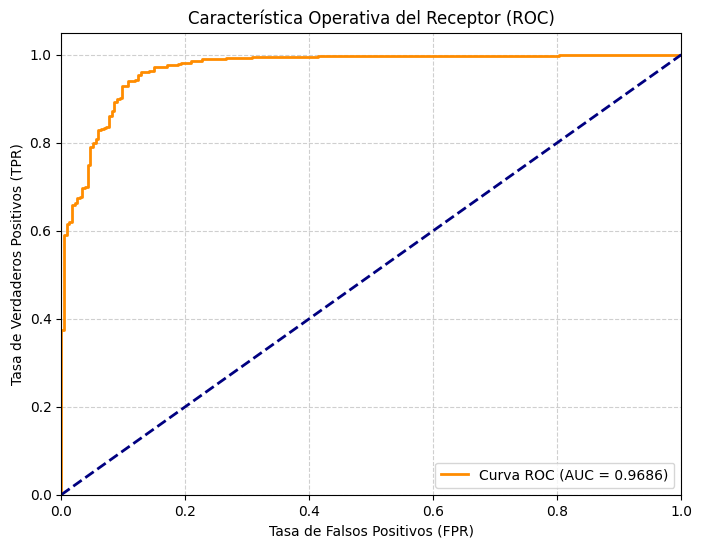

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(Y_true, Y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()